In [ ]:
# https://cs231n.github.io/neural-networks-case-study/

In [1]:
import numpy as np
import matplotlib.pyplot as plt

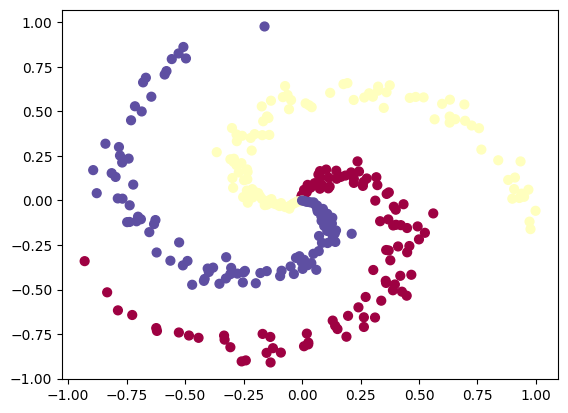

In [2]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [4]:
print(X.shape)

(300, 2)


In [5]:
y = y.reshape(-1,1)
print(y.shape)

(300, 1)


In [10]:
W = 0.01 * np.random.randn(2,3)
b = np.zeros((1,3))

In [11]:
def parameter_loss(W, b):

    
    z = np.dot(X, W) + b
    n = X.shape[0]
    
    exp = np.exp(z)
    
    # sum across rows
    probs = exp / np.sum(exp, axis=1, keepdims=True)

    correct_prob = []
    for i in range(n):
        if y[i] == 0:
            correct_prob.append(-np.log(probs[i][0]))
        elif y[i] == 1:
            correct_prob.append(-np.log(probs[i][1]))
        else:
            correct_prob.append(-np.log(probs[i][2]))

    correct_prob = np.array(correct_prob)

    return np.sum(correct_prob)/n, probs

In [12]:
def regularized_loss(W, reg = 1e-3):

    return 0.5*reg*np.sum(W*W)

In [13]:
def gradients(probs):

    df_probs = probs.copy()
    n = df_probs.shape[0]
    
    for i in range(300):
        if y[i] == 0:
            df_probs[i][0] = df_probs[i][0] - 1
        elif y[i] == 1:
            df_probs[i][1] = df_probs[i][1] - 1
        else:
            df_probs[i][2] = df_probs[i][2] - 1

    df_probs = df_probs / n

    
    return df_probs

In [15]:
num_iters = 400
reg = 1e-3
alpha = 0.1

for i in range(num_iters):

    total_loss, probs = parameter_loss(W, b)
    total_loss = total_loss + regularized_loss(W)
    
    df_probs = gradients(probs)

    dW = np.dot(X.T, df_probs) + reg*W

    db = np.sum(df_probs, axis=0, keepdims=True)

    W = W - alpha*dW
    b = b - alpha*db

    if i % 100 == 0:
        print(f'Iteration {i}, Loss : {total_loss}')


Iteration 0, Loss : 1.0989658622122076
Iteration 10, Loss : 1.068610954807594
Iteration 20, Loss : 1.0415045784606305
Iteration 30, Loss : 1.0172638781225498
Iteration 40, Loss : 0.9955489108688755
Iteration 50, Loss : 0.9760594648322816
Iteration 60, Loss : 0.9585316127850995
Iteration 70, Loss : 0.9427341192018877
Iteration 80, Loss : 0.9284648615001446
Iteration 90, Loss : 0.9155474017976729
Iteration 100, Loss : 0.9038278016813647
Iteration 110, Loss : 0.8931717304505218
Iteration 120, Loss : 0.8834618846195857
Iteration 130, Loss : 0.8745957141154466
Iteration 140, Loss : 0.8664834369608486
Iteration 150, Loss : 0.8590463170351145
Iteration 160, Loss : 0.8522151766741608
Iteration 170, Loss : 0.8459291157938952
Iteration 180, Loss : 0.8401344107369005
Iteration 190, Loss : 0.8347835683750633
Iteration 200, Loss : 0.8298345136562688
Iteration 210, Loss : 0.8252498914641478
Iteration 220, Loss : 0.8209964661993868
Iteration 230, Loss : 0.8170446048061034
Iteration 240, Loss : 0.8133

In [16]:
print(W)
print(b)

[[ 0.82812359  0.80911095 -1.64462039]
 [-1.6733149   1.88620146 -0.22868514]]
[[-0.01563646  0.00148322  0.01415323]]


In [17]:
z_learned = np.dot(X, W) + b

In [18]:
z_learned_exp = np.exp(z_learned)

In [19]:
exp_pred = z_learned_exp / np.sum(z_learned_exp, axis=1, keepdims=True)

In [20]:
y_pred = np.argmax(exp_pred, axis=1)

In [21]:
y_pred = y_pred.reshape(-1,1)

In [ ]:
np.sum(y_pred == y) / len(y)

## Neural Network - I

One hidden layer with reLU activation function between input and hidden layer, and softmax between hidden and output layer

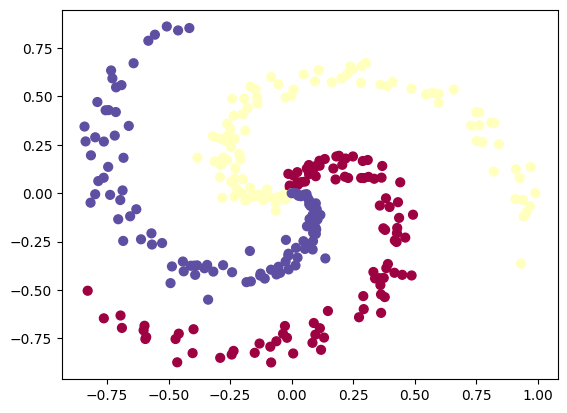

In [3]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [4]:
n = X.shape[0]

In [5]:
w1 = np.random.randn(2, 100)*0.01
b1 = np.zeros((1, 100))

w2 = np.random.randn(100, 3)*0.01
b2 = np.zeros((1, 3))

In [6]:
def forward_pass(w1, b1, w2, b2):

    z1 = np.dot(X, w1) + b1
    g1 = np.maximum(z1, 0)

    z = np.dot(g1, w2) + b2

    exp_z = np.exp(z)
    
    # sum across rows
    pred_probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return pred_probs, z1, g1, z

In [7]:
def parameter_loss(pred_probs):
    
    correct_logprobs = []
    
    for i in range(n):
        if y[i] == 0:
            correct_logprobs.append(-np.log(pred_probs[i][0]))
        elif y[i] == 1:
            correct_logprobs.append(-np.log(pred_probs[i][1]))
        else:
            correct_logprobs.append(-np.log(pred_probs[i][2]))

    correct_logprobs = np.array(correct_logprobs)
    loss = np.mean(correct_logprobs)

    return loss

In [8]:
def regularized_loss(w1, w2, reg = 1e-3):

    return 0.5*reg*np.sum(w1*w1) + 0.5*reg*np.sum(w2*w2)

In [9]:
def dz_gradient(probs):

    pred_probs_dz = probs.copy()
    
    for i in range(n):
        if y[i] == 0:
            pred_probs_dz[i][0] = pred_probs_dz[i][0] - 1
        elif y[i] == 1:
            pred_probs_dz[i][1] = pred_probs_dz[i][1] - 1
        else:
            pred_probs_dz[i][2] = pred_probs_dz[i][2] - 1
            
    return pred_probs_dz

In [11]:
reg = 1e-3
alpha = 0.1
num_iters = 10000

In [12]:
for i in range(num_iters):

    pred_probs, z1, g1, z = forward_pass(w1, b1, w2, b2)
    
    loss = parameter_loss(pred_probs)
    total_loss = loss + regularized_loss(w1, w2)

    pred_probs_dz = dz_gradient(pred_probs)

    # dw2 = (dL/dz)*(dz/dw2)
    # dL/dz = pred_probs_dz
    # dz/dw2 = g1
    dw2 = (g1.T @ pred_probs_dz) / n

    # db2 = (dL/dz)*(dz/db2)
    # dL/dz = pred_probs_dz
    # dz/dwb2 = 1
    db2 = np.mean(pred_probs_dz, axis=0)

    
    # dw1 = (dL/dz)*(dz/dg1)*(dg1/dz1)*(dz1/dw1)
    # dL/dz = pred_probs_dz
    # dz/dg1 = w2
    # dg1/dz1 = derivative of reLU
    # dz1/dw1 = X
    dg1 = pred_probs_dz @ w2.T
    dg1[z1 <= 0] = 0
    dw1 = ((dg1.T) @ X).T / n

    # db1 = (dL/dz)*(dz/dg1)*(dg1/dz1)*(dz1/db1)

    # dL/dz = pred_probs_dz
    # dz/dg1 = w2
    # dg1/dz1 = derivative of reLU
    # dz1/db1 = 1

    dg1 = pred_probs_dz @ w2.T
    dg1[z1 <= 0] = 0
    db1 = np.mean(dg1, axis=0)

    dw2 = dw2 + reg * w2
    dw1 = dw1 + reg * w1

    
    w1 = w1 - alpha * dw1
    b1 = b1 - alpha * db1
    w2 = w2 - alpha * dw2
    b2 = b2 - alpha * db2

    if i % 1000 == 0:
        print(f"Iteration {i}, Loss: {total_loss}")

Iteration 0, Loss: 1.0987599853183827
Iteration 1000, Loss: 0.7014308371651005
Iteration 2000, Loss: 0.6466923015493956
Iteration 3000, Loss: 0.46405380804266805
Iteration 4000, Loss: 0.3575717404146471
Iteration 5000, Loss: 0.3263959704262435
Iteration 6000, Loss: 0.3133527783821642
Iteration 7000, Loss: 0.30507856030704356
Iteration 8000, Loss: 0.2997341377776611
Iteration 9000, Loss: 0.29536777005366244


In [13]:
z1 = X @ w1 + b1
g1 = np.maximum(z1, 0)

z = g1 @ w2 + b2
exp_z = np.exp(z)

y_pred = np.argmax(exp_z, axis=1)

accuracy = np.mean(y_pred == y)

In [14]:
print(f'Accuracy: {accuracy}')

Accuracy: 0.94


## Neural Network - II

One hidden layer with sigmoid activation function between input and hidden layer, and softmax between hidden and output layer

In [56]:
import numpy as np
import matplotlib.pyplot as plt

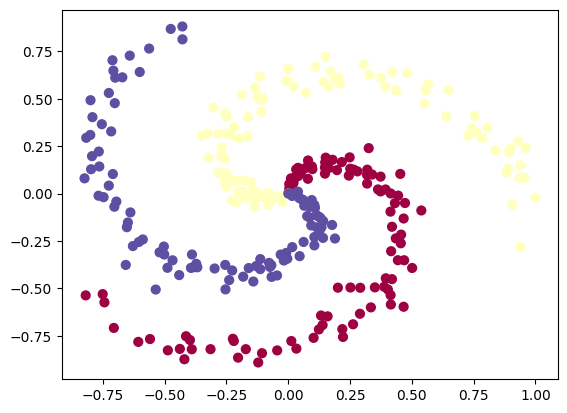

In [3]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [4]:
n = X.shape[0]

In [5]:
w1 = np.random.randn(2, 100)*0.01
b1 = np.zeros((1, 100))

w2 = np.random.randn(100, 3)*0.01
b2 = np.zeros((1, 3))

In [6]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [7]:
def forward_pass(w1, b1, w2, b2):
    
    z1 = X @ w1 + b1
    g1 = sigmoid(z1)
    z = g1 @ w2 + b2

    exp_z = np.exp(z)
    pred_probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    return pred_probs, z1, g1, z

In [8]:
def parameter_loss(probs):

    correct_logprobs = []

    for i in range(n):
        if y[i] == 0:
            correct_logprobs.append(-np.log(probs[i][0]))
        elif y[i] == 1:
            correct_logprobs.append(-np.log(probs[i][1]))
        else:
            correct_logprobs.append(-np.log(probs[i][2]))

    correct_logprobs = np.array(correct_logprobs)
    loss = np.mean(correct_logprobs)

    return loss

In [9]:
def regularized_loss(w1, w2, reg = 1e-3):

    return 0.5*reg*np.sum(w1*w1) + 0.5*reg*np.sum(w2*w2)

In [10]:
def gradient_dz(probs):

    probs_dz = np.copy(probs)

    for i in range(n):
        if y[i] == 0:
            probs_dz[i][0] = probs_dz[i][0] - 1
        elif y[i] == 1:
            probs_dz[i][1] = probs_dz[i][1] - 1
        else:
            probs_dz[i][2] = probs_dz[i][2] - 1

    return probs_dz

In [11]:
reg = 1e-3
alpha = 1
num_iters = 10000

In [13]:
for i in range(num_iters):

    pred_probs, z1, g1, z = forward_pass(w1, b1, w2, b2)
    total_loss = parameter_loss(pred_probs)

    total_loss = total_loss + regularized_loss(w1, w2)
    probs_dz = gradient_dz(pred_probs)

    dw2 = (g1.T @ probs_dz) / n
    db2 = np.mean(probs_dz, axis=0)
    
    dw1 = (((probs_dz @ w2.T) * (g1*(1-g1))).T @ X).T / n
    db1 = np.mean((probs_dz @ w2.T) * (g1 *(1 - g1)), axis=0)

    dw2 = dw2 + reg * w2
    dw1 = dw1 + reg * w1

    w1 = w1 - alpha * dw1
    b1 = b1 - alpha * db1
    w2 = w2 - alpha * dw2
    b2 = b2 - alpha * db2

    if i % 1000 == 0:
        print(f"Iteration {i}, Loss: {total_loss}")

Iteration 0, Loss: 1.099099365096055
Iteration 1000, Loss: 0.7615710270003092
Iteration 2000, Loss: 0.7424906045895001
Iteration 3000, Loss: 0.5766127931975613
Iteration 4000, Loss: 0.530757473392907
Iteration 5000, Loss: 0.527027183827039
Iteration 6000, Loss: 0.5250934223817461
Iteration 7000, Loss: 0.5238545038661986
Iteration 8000, Loss: 0.5295144354685265
Iteration 9000, Loss: 0.5290998280800374


In [14]:
z1 = X @ w1 + b1
g1 = sigmoid(z1)

z = g1 @ w2 + b2
exp_z = np.exp(z)

y_pred = np.argmax(exp_z, axis = 1)

accuracy = np.mean(y_pred == y)

In [15]:
print(f'Accuracy: {accuracy}')

Accuracy: 0.91


## Neural Network - III

Two hidden layer with sigmoid activation function between input and hidden layer 1 and between hidden layer 1 and hidden layer 2, and softmax between hidden layer 2 and output layer

In [57]:
import numpy as np
import matplotlib.pyplot as plt

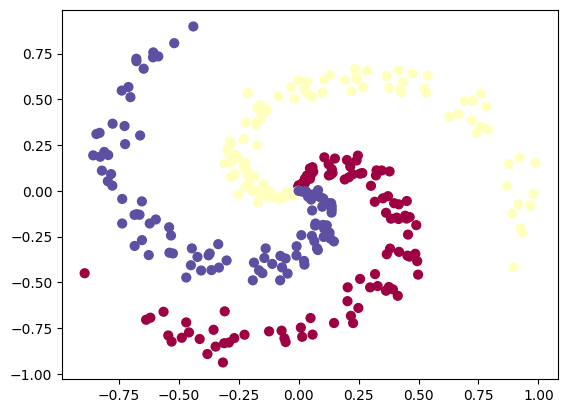

In [2]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [14]:
n = X.shape[0]

In [5]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [6]:
def forward_pass(w1, b1, w2, b2, w3, b3):

    z1 = X @ w1 + b1
    g1 = sigmoid(z1)

    z2 = g1 @ w2 + b2
    g2 = sigmoid(z2)
    
    z = g2 @ w3 + b3

    exp_z = np.exp(z)
    probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return probs, z, g2, z2, g1, z1

In [7]:
def parameter_loss(probs):

    correct_logprobs = []

    for i in range(n):
        if y[i] == 0:
            correct_logprobs.append(-np.log(probs[i][0]))
        elif y[i] == 1:
            correct_logprobs.append(-np.log(probs[i][1]))
        else:
            correct_logprobs.append(-np.log(probs[i][2]))

    correct_logprobs = np.array(correct_logprobs)
    loss = np.mean(correct_logprobs)

    return loss

In [8]:
def regularized_loss(w1, w2, w3, reg = 1e-3):

    return 0.5*reg*np.sum(w1*w1) + 0.5*reg*np.sum(w2*w2) + 0.5*reg*np.sum(w3*w3)

In [9]:
def gradient_dz(probs):

    probs_dz = np.copy(probs)

    for i in range(n):
        if y[i] == 0:
            probs_dz[i][0] = probs_dz[i][0] - 1
        elif y[i] == 1:
            probs_dz[i][1] = probs_dz[i][1] - 1
        else:
            probs_dz[i][2] = probs_dz[i][2] - 1

    return probs_dz

In [48]:
w1 = np.random.randn(2, 64)*0.01
b1 = np.zeros((1, 64))

w2 = np.random.randn(64, 32)*0.01
b2 = np.zeros((1, 32))

w3 = np.random.randn(32, 3)*0.01
b3 = np.zeros((1, 3))

In [49]:
reg = 1e-3
alpha = 2
num_iters = 10000

In [50]:
for i in range(num_iters):

    probs, z, g2, z2, g1, z1 = forward_pass(w1, b1, w2, b2, w3, b3)
    total_loss = parameter_loss(probs)

    total_loss = total_loss + regularized_loss(w1, w2, w3)
    probs_dz = gradient_dz(probs)

    dw3 = (g2.T @ probs_dz) / n
    db3 = np.mean(probs_dz, axis=0)
    
    dg2 = probs_dz @ w3.T
    dw2 = g1.T @ (dg2*g2*(1-g2)) / n

    db2 = np.mean(dg2*g2*(1-g2), axis=0)

    dw1 = X.T @ ((dg2*g2*(1-g2)) @ w2.T * g1*(1-g1)) / n
    db1 = np.mean(((dg2*g2*(1-g2) @ w2.T)*g1*(1-g1)), axis=0)

    
    dw3 = dw3 + reg * w3
    dw2 = dw2 + reg * w2
    dw1 = dw1 + reg * w1

    w1 = w1 - alpha * dw1
    b1 = b1 - alpha * db1
    w2 = w2 - alpha * dw2
    b2 = b2 - alpha * db2
    w3 = w3 - alpha * dw3
    b3 = b3 - alpha * db3

    if i % 1000 == 0:
        print(f"Iteration {i}, Loss: {total_loss}")

Iteration 0, Loss: 1.1001535562686555
Iteration 1000, Loss: 0.9365328473555173
Iteration 2000, Loss: 0.9358358809170161
Iteration 3000, Loss: 0.9358737677817945
Iteration 4000, Loss: 0.9356467603381298
Iteration 5000, Loss: 0.7579270342048314
Iteration 6000, Loss: 0.6659756118030358
Iteration 7000, Loss: 0.6308360573957869
Iteration 8000, Loss: 0.616257470274113
Iteration 9000, Loss: 0.6092397217697633


In [53]:
z1 = X @ w1 + b1
g1 = sigmoid(z1)

z2 = g1 @ w2 + b2
g2 = sigmoid(z2)

z = g2 @ w3 + b3

exp_z = np.exp(z)
y_pred = np.argmax(exp_z, axis=1)

accuracy = np.mean(y_pred == y)

In [54]:
print(f'Accuracy: {accuracy}')

np.float64(0.87)

## Neural Network - IV

Two hidden layer with reLU activation function between input and hidden layer 1 and between hidden layer 1 and hidden layer 2, and softmax between hidden layer 2 and output layer

In [1]:
import numpy as np
import matplotlib.pyplot as plt

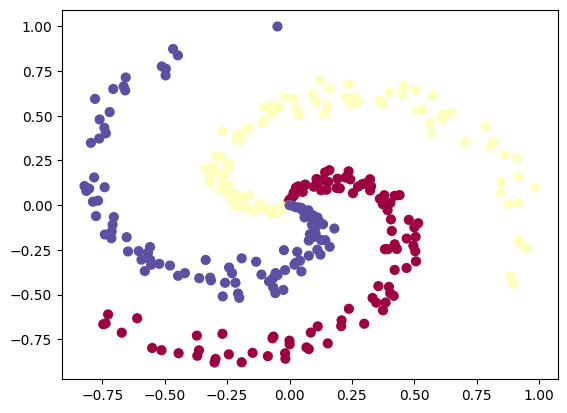

In [2]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [3]:
n = X.shape[0]

In [4]:
w1 = np.random.randn(2, 64)*0.01
b1 = np.zeros((1, 64))

w2 = np.random.randn(64, 32)*0.01
b2 = np.zeros((1, 32))

w3 = np.random.randn(32, 3)*0.01
b3 = np.zeros((1, 3))

In [5]:
def forward_pass(w1, b1, w2, b2, w3, b3):

    z1 = X @ w1 + b1
    g1 = np.maximum(z1, 0)

    z2 = g1 @ w2 + b2
    g2 = np.maximum(z2, 0)
    
    z = g2 @ w3 + b3

    exp_z = np.exp(z)
    probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return probs, z, g2, z2, g1, z1

In [6]:
def parameter_loss(probs):

    correct_logprobs = []

    for i in range(n):
        if y[i] == 0:
            correct_logprobs.append(-np.log(probs[i][0]))
        elif y[i] == 1:
            correct_logprobs.append(-np.log(probs[i][1]))
        else:
            correct_logprobs.append(-np.log(probs[i][2]))

    correct_logprobs = np.array(correct_logprobs)
    loss = np.mean(correct_logprobs)

    return loss

In [7]:
def regularized_loss(w1, w2, w3, reg = 1e-3):

    return 0.5*reg*np.sum(w1*w1) + 0.5*reg*np.sum(w2*w2) + 0.5*reg*np.sum(w3*w3)

In [8]:
def gradient_dz(probs):

    probs_dz = np.copy(probs)

    for i in range(n):
        if y[i] == 0:
            probs_dz[i][0] = probs_dz[i][0] - 1
        elif y[i] == 1:
            probs_dz[i][1] = probs_dz[i][1] - 1
        else:
            probs_dz[i][2] = probs_dz[i][2] - 1

    return probs_dz

In [16]:
w1 = np.random.randn(2, 64)*0.01
b1 = np.zeros((1, 64))

w2 = np.random.randn(64, 32)*0.01
b2 = np.zeros((1, 32))

w3 = np.random.randn(32, 3)*0.01
b3 = np.zeros((1, 3))

In [17]:
reg = 1e-3
alpha = 1
num_iters = 10000

In [18]:
for k in range(num_iters):

    probs, z, g2, z2, g1, z1 = forward_pass(w1, b1, w2, b2, w3, b3)
    total_loss = parameter_loss(probs)

    total_loss = total_loss + regularized_loss(w1, w2, w3)
    probs_dz = gradient_dz(probs)

    dw3 = (g2.T @ probs_dz) / n
    db3 = np.mean(probs_dz, axis=0)
    

    dL_dg2 = probs_dz @ w3.T
    dg2_dz2 = np.zeros_like(z2)

    for i in range(z2.shape[0]):
        for j in range(z2.shape[1]):
            if z2[i, j] > 0:
                dg2_dz2[i, j] = 1
            else:
                dg2_dz2[i, j] = 0
    
    dL_dz2 = dL_dg2 * dg2_dz2
    dw2 = (g1.T @ dL_dz2) / n
    db2 = np.mean(dL_dz2, axis=0)
    
    dL_dg2 = probs_dz @ w3.T

    dg2_dz2 = np.zeros_like(z2)

    for i in range(z2.shape[0]):
        for j in range(z2.shape[1]):
            if z2[i, j] > 0:
                dg2_dz2[i, j] = 1
            else:
                dg2_dz2[i, j] = 0

    dL_dz2 = dL_dg2 * dg2_dz2
    dL_dg1 = dL_dz2 @ w2.T
    
    dg1_dz1 = np.zeros_like(z1)
    for i in range(z1.shape[0]):
        for j in range(z1.shape[1]):
            if z1[i, j] > 0:
                dg1_dz1[i, j] = 1
            else:
                dg1_dz1[i, j] = 0
    
    dL_dz1 = dL_dg1 * dg1_dz1
    
    dw1 = X.T @ dL_dz1 / n
    db1 = np.mean(dL_dz1, axis=0)
    
    dw3 = dw3 + reg * w3
    dw2 = dw2 + reg * w2
    dw1 = dw1 + reg * w1

    w1 = w1 - alpha * dw1
    b1 = b1 - alpha * db1
    w2 = w2 - alpha * dw2
    b2 = b2 - alpha * db2
    w3 = w3 - alpha * dw3
    b3 = b3 - alpha * db3

    if k % 1000 == 0:
        print(f"Iteration {k}, Loss: {total_loss}")

Iteration 0, Loss: 1.0987292383942737
Iteration 1000, Loss: 0.1555975297980981
Iteration 2000, Loss: 0.13493278986627325
Iteration 3000, Loss: 0.12611063043257328
Iteration 4000, Loss: 0.13670566433938772
Iteration 5000, Loss: 0.13494398396062712
Iteration 6000, Loss: 0.12455551092132741
Iteration 7000, Loss: 0.12412495113716679
Iteration 8000, Loss: 0.131294184778889
Iteration 9000, Loss: 0.13253601300697448


In [19]:
z1 = X @ w1 + b1
g1 = np.maximum(z1, 0)

z2 = g1 @ w2 + b2
g2 = np.maximum(z2, 0)

z = g2 @ w3 + b3

exp_z = np.exp(z)
y_pred = np.argmax(exp_z, axis=1)

accuracy = np.mean(y_pred == y)

In [21]:
print(f'Accuracy: {accuracy}')

Accuracy: 0.9766666666666667
